# NoteMap: Visualizing Domain Knowledge Graphically

# Ingestion

In [32]:
from pathlib import Path
from IPython.display import Image, display

import os
from anthropic import Anthropic
from dotenv import load_dotenv


from notemap.ingest.pdf import rasterize_pdf, transcribe_page, save_pdfs
from notemap.cache import content_hash

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
PDF_IN_PATH = "notes/pdfs"
OUT_PATH = "data"
client = Anthropic()


In [ ]:
save_pdfs(PDF_IN_PATH, OUT_PATH, client=client)

  page 0: transcribed
  page 1: transcribed
  page 2: transcribed
  page 3: transcribed
  page 4: transcribed
Ingested and saved JSON data for  data/pitchbook_prep_77a66636.json
  page 0: transcribed


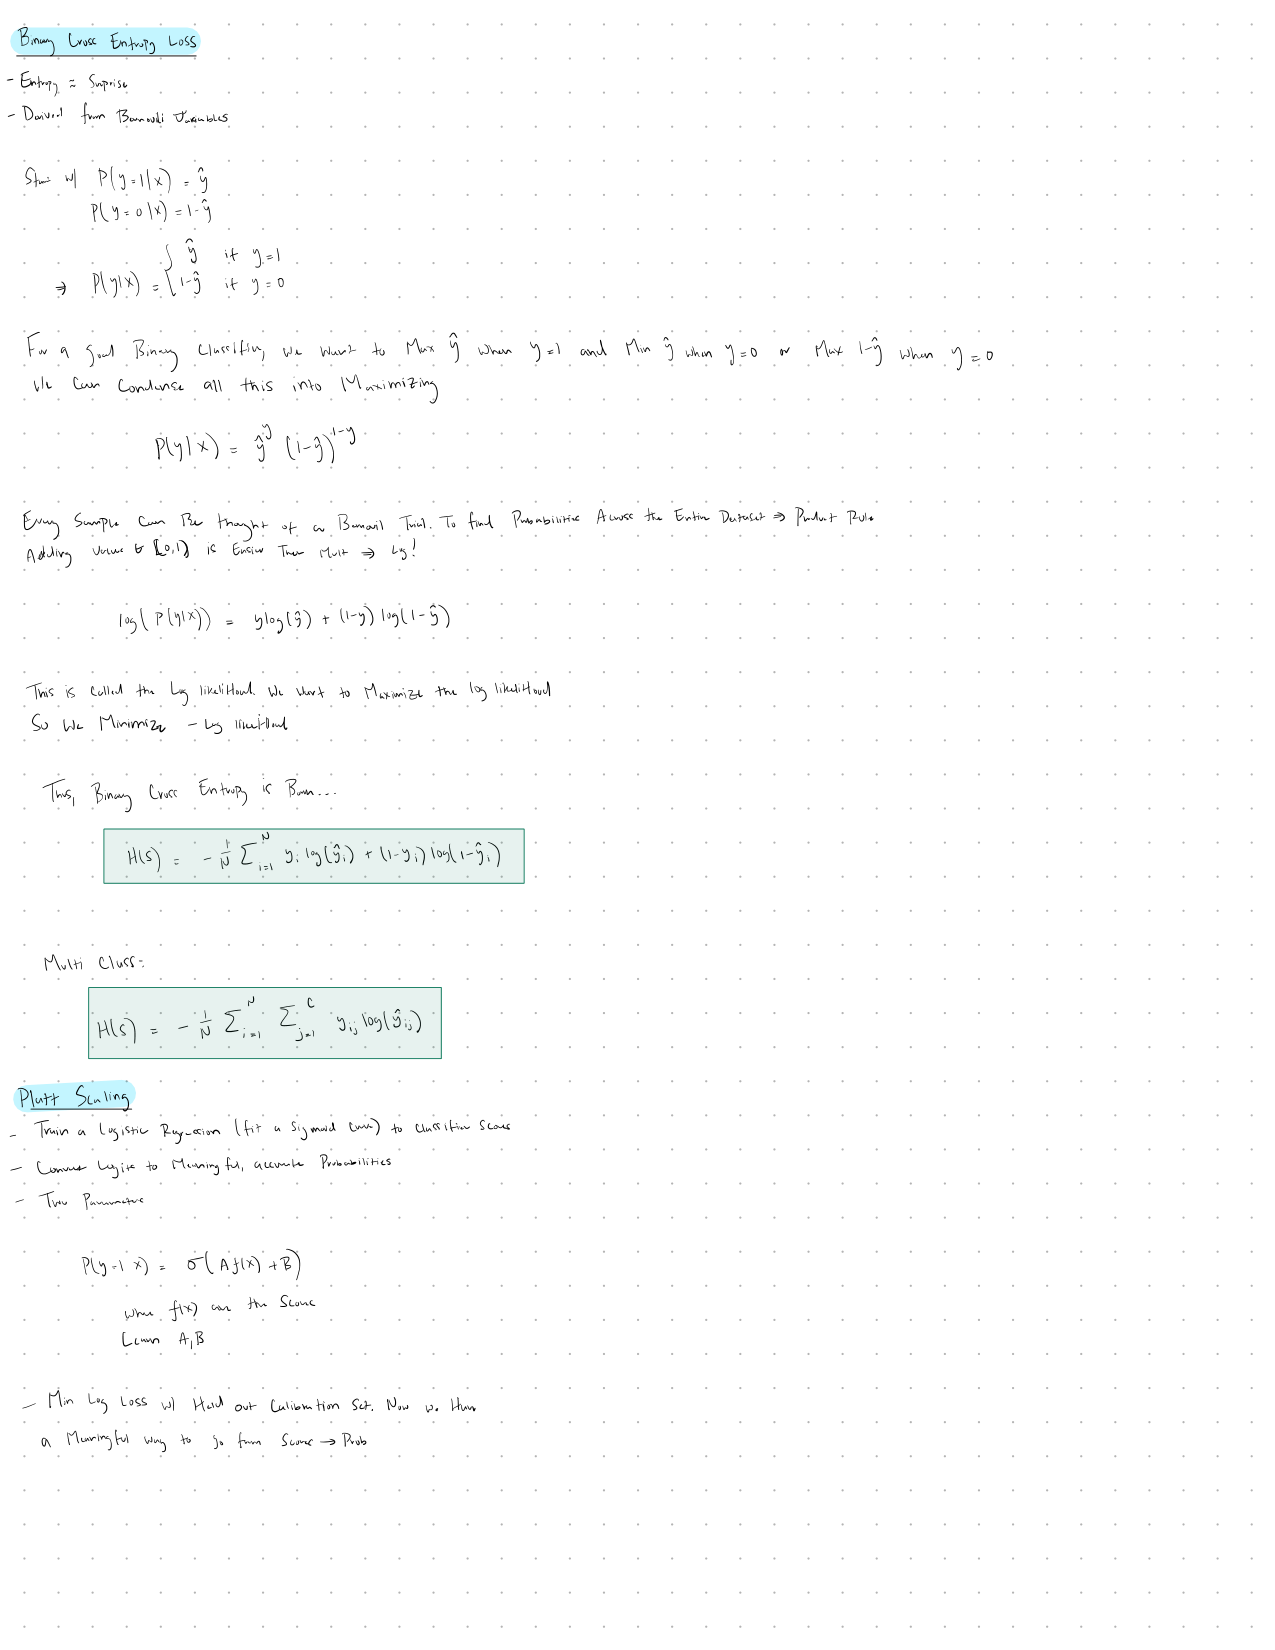

In [ ]:
pages = rasterize_pdf(PDF_PATH + "/pitchbook_prep.pdf")

page_num, page_bytes = pages[3]
display(Image(data=page_bytes))

In [6]:
load_dotenv()
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
data_dir = Path("data")
image_hash = content_hash(page_bytes)
text = transcribe_page(image_bytes=page_bytes, client=client, data_dir=data_dir, image_hash=image_hash)
print(text)

# Binary Cross Entropy Loss

- Entropy = Surprise
- Derived from Bernoulli Distributions

Say if $P(y=1|x) = \hat{y}$
$P(y=0|x) = 1-\hat{y}$

$$\Rightarrow P(y|x) = \begin{cases} \hat{y} & \text{if } y=1 \\ 1-\hat{y} & \text{if } y=0 \end{cases}$$

For a good Binary Classifier, we want to Max $\hat{y}$ when $y=1$ and Min $\hat{y}$ when $y=0$ or Max $1-\hat{y}$ when $y=0$. We can condense all this into Maximizing

$$P(y|x) = \hat{y}^y (1-\hat{y})^{1-y}$$

Every Sample can be thought of as a Bernoulli Trial. To find Probabilistic Answer for the Entire Dataset $\Rightarrow$ Product Rule. Adding values to $[0,1]$ is Easier Than Mult $\Rightarrow$ log!

$$\log(P(y|x)) = y\log(\hat{y}) + (1-y)\log(1-\hat{y})$$

This is called the Log Likelihood. We want to Maximize the log likelihood. So we Minimize $-$ log likelihood.

Thus, Binary Cross Entropy is Born...

$$\boxed{H(\hat{s}) = -\frac{1}{N} \sum_{i=1}^{N} y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)}$$

## Multi Class:

$$\boxed{H(\hat{s

In [ ]:
save_pdfs()